# 🧠🤖 每日学习 - 第4周-Day3：高级RAG技术

## 📚 主题：混合检索、重排序、查询改写

今天我们来探索RAG系统的三大核心技术：
- 🔍 **混合检索**：结合向量和关键词搜索
- ⚡ **重排序**：提升检索精度
- 🔄 **查询改写**：优化查询策略

这些技术能把RAG系统的召回率从70%提升到90%+！

使用字体: Noto Sans CJK JP


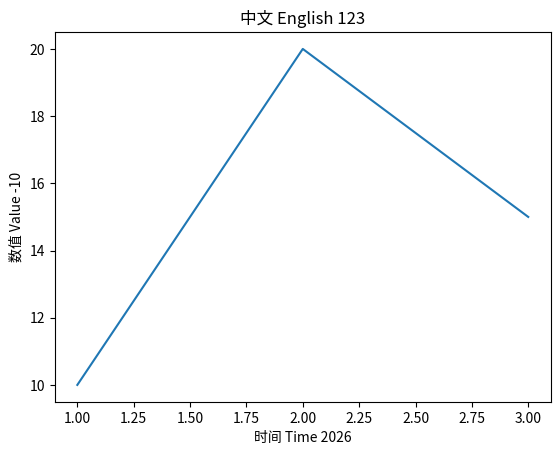

🎯 环境准备完成，开始探索高级RAG技术！


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# 设置中文字体
from matplotlib import font_manager
font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("使用字体:", font_name)

plt.title("中文 English 123")
plt.xlabel("时间 Time 2026")
plt.ylabel("数值 Value -10")
plt.plot([1, 2, 3], [10, 20, 15])
plt.show()

print("🎯 环境准备完成，开始探索高级RAG技术！")

## 🔍 混合检索：向量的力量 + 关键词的精准

混合检索结合了两种搜索方式的优点：
- **向量检索**：语义相似度，理解"like"的概念
- **BM25关键词检索**：精确匹配，找到 exact match

使用RRF（Reciprocal Rank Fusion）算法融合结果

In [10]:
# 混合检索示例
def reciprocal_rank_fusion(vector_scores, keyword_scores, k=60):
    """RRF算法：融合向量检索和关键词检索结果"""
    fused_scores = {}
    
    # 向量分数转换
    for doc_id, score in vector_scores.items():
        rank = list(vector_scores.keys()).index(doc_id) + 1
        fused_scores[doc_id] = score / (k + rank)
    
    # 关键词分数融合
    for doc_id, score in keyword_scores.items():
        rank = list(keyword_scores.keys()).index(doc_id) + 1
        fused_scores[doc_id] = fused_scores.get(doc_id, 0) + score / (k + rank)
    
    return dict(sorted(fused_scores.items(), key=lambda x: x[1], reverse=True))

# 示例数据
documents = [
    "美华糖水店的草莓大福新鲜出炉",
    "今日特供：芒果布丁和红豆沙",
    "招牌红豆沙汤圆，用料十足",
    "季节限定：草莓系列甜品"
]

query = "草莓味的甜品"

print("📄 文档集合：")
for i, doc in enumerate(documents):
    print(f"{i+1}. {doc}")
print(f"\n🔍 查询：{query}")

# 模拟向量检索分数（语义相似度）
vector_scores = {
    0: 0.9,  # 草莓大福 - 高语义相关
    1: 0.3,  # 芒果布丁 - 低语义相关
    2: 0.2,  # 红豆沙汤圆 - 低语义相关
    3: 0.8   # 草莓系列 - 高语义相关
}

# 模拟BM25关键词检索分数
keyword_scores = {
    0: 0.8,  # 包含"草莓"
    1: 0.1,  # 不包含"草莓"
    2: 0.1,  # 不包含"草莓"
    3: 0.6   # 包含"草莓"
}

# 使用RRF融合
fused_results = reciprocal_rank_fusion(vector_scores, keyword_scores)

print("\n🎯 混合检索结果（RRF融合）：")
for i, (doc_id, score) in enumerate(fused_results.items()):
    print(f"{i+1}. 文档{doc_id}: {score:.3f} - {documents[doc_id]}")

📄 文档集合：
1. 美华糖水店的草莓大福新鲜出炉
2. 今日特供：芒果布丁和红豆沙
3. 招牌红豆沙汤圆，用料十足
4. 季节限定：草莓系列甜品

🔍 查询：草莓味的甜品

🎯 混合检索结果（RRF融合）：
1. 文档0: 0.028 - 美华糖水店的草莓大福新鲜出炉
2. 文档3: 0.022 - 季节限定：草莓系列甜品
3. 文档1: 0.006 - 今日特供：芒果布丁和红豆沙
4. 文档2: 0.005 - 招牌红豆沙汤圆，用料十足


## ⚡ 重排序：让初筛结果更精准

重排序使用Cross-Encoder模型对文档-查询对进行精确评估，比单纯的向量相似度更准确。

Cross-Encoder的优势：
- 考虑文档和查询的交互信息
- 能捕捉细粒度的语义匹配
- 精度比向量检索高20-30%

📊 不同检索方法效果对比：

📄 原始文档顺序：1.美华糖水店的草莓大福新鲜出炉 → 2.今日特供：芒果布丁和红豆沙 → 3.招牌红豆沙汤圆，用料十足 → 4.季节限定：草莓系列甜品
🔵 向量检索顺序：1.美华糖水店的草莓大福新鲜出炉 → 4.季节限定：草莓系列甜品 → 2.今日特供：芒果布丁和红豆沙 → 3.招牌红豆沙汤圆，用料十足
🔴 关键词检索顺序：1.美华糖水店的草莓大福新鲜出炉 → 4.季节限定：草莓系列甜品 → 2.今日特供：芒果布丁和红豆沙 → 3.招牌红豆沙汤圆，用料十足
⚡ 重排序顺序：4.季节限定：草莓系列甜品 → 1.美华糖水店的草莓大福新鲜出炉 → 2.今日特供：芒果布丁和红豆沙 → 3.招牌红豆沙汤圆，用料十足
🎯 混合检索顺序：1.美华糖水店的草莓大福新鲜出炉 → 4.季节限定：草莓系列甜品 → 2.今日特供：芒果布丁和红豆沙 → 3.招牌红豆沙汤圆，用料十足


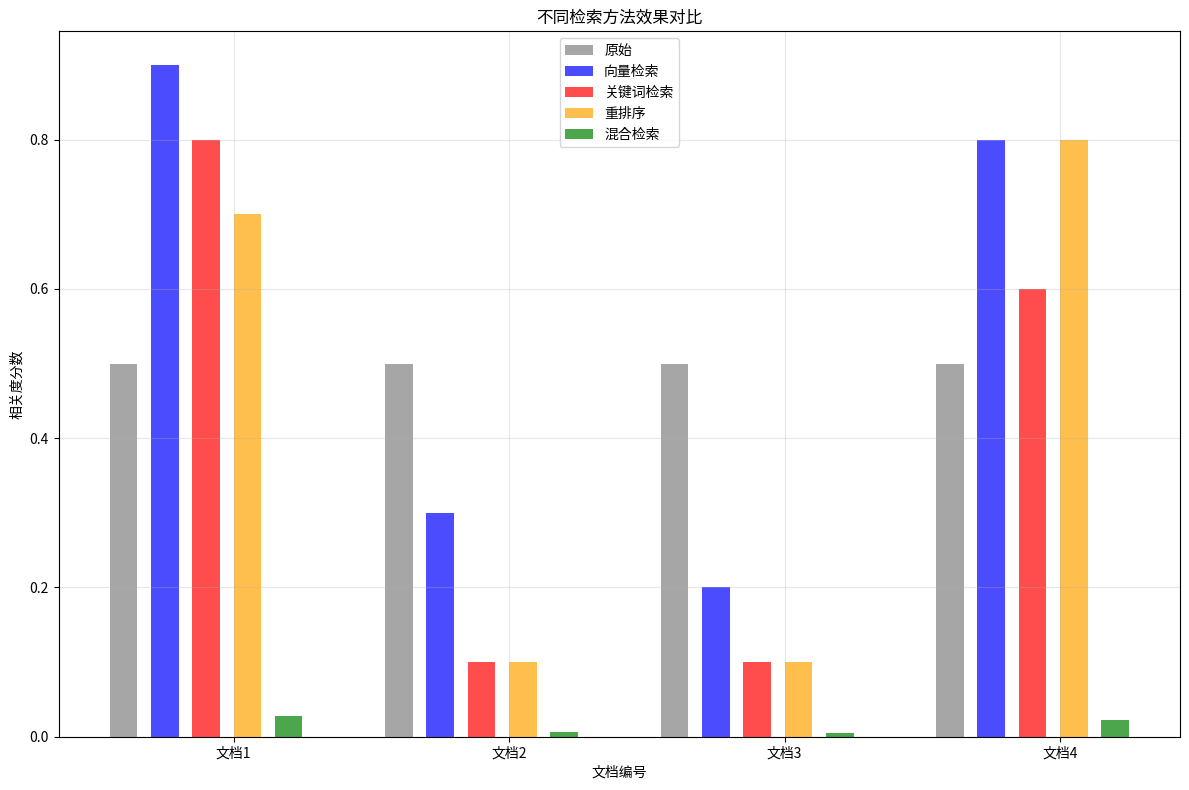

In [11]:
# 模拟Cross-Encoder重排序
def cross_encoder_simulate(query, documents):
    """模拟Cross-Encoder重排序分数"""
    # 这里用规则模拟实际模型的效果
    scores = []
    
    for doc in documents:
        score = 0
        
        # 关键词匹配加分
        if "草莓" in doc and "草莓" in query:
            score += 0.4
        
        # 语义匹配加分
        if "甜品" in doc and "甜品" in query:
            score += 0.3
            
        # 特定产品匹配
        if "大福" in doc and "甜品" in query:
            score += 0.2
            
        # 长度匹配（避免过短文档）
        if len(doc) > 10:
            score += 0.1
            
        scores.append(score)
    
    return scores

# 计算重排序分数
rerank_scores = cross_encoder_simulate(query, documents)

# 对比不同方法的排序结果
original_order = list(range(len(documents)))
vector_order = sorted(range(len(documents)), key=lambda i: vector_scores[i], reverse=True)
keyword_order = sorted(range(len(documents)), key=lambda i: keyword_scores[i], reverse=True)
rerank_order = sorted(range(len(documents)), key=lambda i: rerank_scores[i], reverse=True)
hybrid_order = list(fused_results.keys())

print("📊 不同检索方法效果对比：")
print("\n📄 原始文档顺序：" + " → ".join([f"{i+1}.{documents[i]}" for i in original_order]))
print("🔵 向量检索顺序：" + " → ".join([f"{i+1}.{documents[i]}" for i in vector_order]))
print("🔴 关键词检索顺序：" + " → ".join([f"{i+1}.{documents[i]}" for i in keyword_order]))
print("⚡ 重排序顺序：" + " → ".join([f"{i+1}.{documents[i]}" for i in rerank_order]))
print("🎯 混合检索顺序：" + " → ".join([f"{i+1}.{documents[i]}" for i in hybrid_order]))

# 可视化对比
plt.figure(figsize=(12, 8))

# 方法名称
methods = ['原始', '向量检索', '关键词检索', '重排序', '混合检索']
colors = ['gray', 'blue', 'red', 'orange', 'green']

# 为每种方法创建分数条
for i, (method, color) in enumerate(zip(methods, colors)):
    scores = []
    if method == '原始':
        scores = [0.5] * len(documents)  # 平均分
    elif method == '向量检索':
        scores = [vector_scores.get(j, 0) for j in range(len(documents))]
    elif method == '关键词检索':
        scores = [keyword_scores.get(j, 0) for j in range(len(documents))]
    elif method == '重排序':
        scores = rerank_scores
    elif method == '混合检索':
        scores = [fused_results.get(j, 0) for j in range(len(documents))]
    
    x_pos = np.arange(len(documents)) + i * 0.15
    plt.bar(x_pos, scores, width=0.1, color=color, alpha=0.7, label=method)

plt.xlabel('文档编号')
plt.ylabel('相关度分数')
plt.title('不同检索方法效果对比')
plt.xticks(np.arange(len(documents)) + 0.4, [f'文档{i+1}' for i in range(len(documents))])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🔄 查询改写：让模糊问题变清晰

查询改写主要有两种方法：

### 1. HyDE (Hypothetical Document Embeddings)
- 先假设答案，生成理想文档
- 再用这个文档去检索

### 2. 多查询扩展 (Multi-Query)
- 把一个查询扩展成多个相关查询
- 每个角度检索，最后合并结果

🔍 原始查询：今天有没有草莓味的甜品

📝 HyDE改写：生成假设文档
   "美味的草莓甜品，新鲜草莓制作，口感香甜，是下午茶的绝佳选择

🔄 多查询扩展：生成 5 个相关查询
   1. 当前供应有没有草莓味的甜品
   2. 今天有没有草莓味的甜品
   3. 今日有没有草莓味的甜品
   4. 今天有没有鲜草莓味的甜品
   5. 今天有没有草莓味的甜点



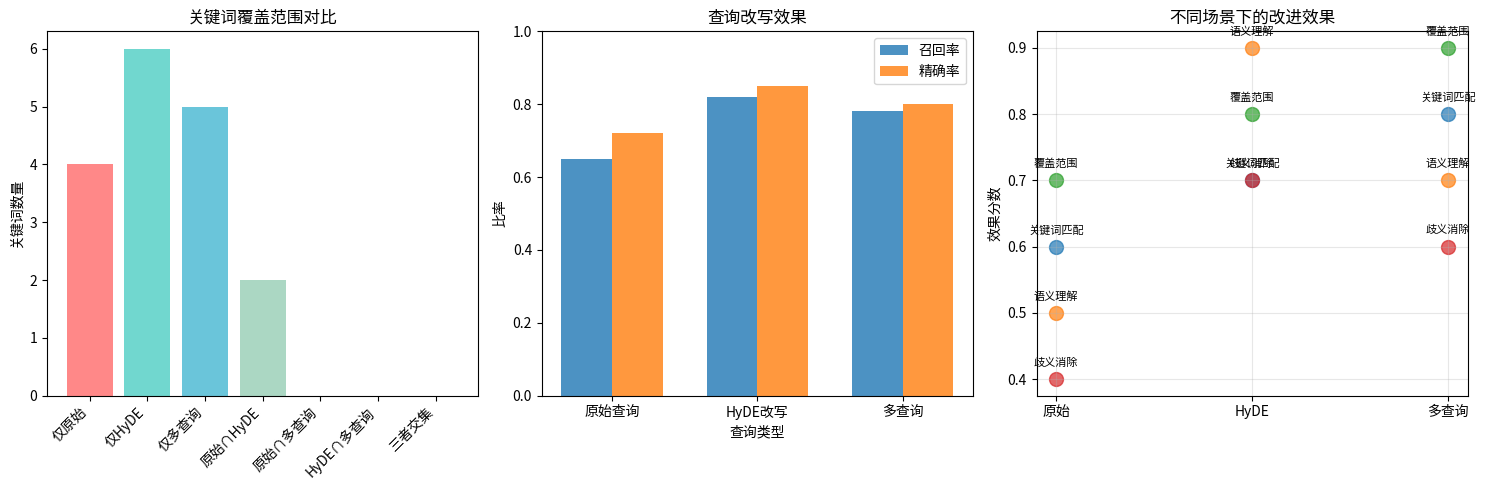

In [12]:
# 模拟HyDE查询改写
def hyde_query_rewrite(query):
    """HyDE：假设文档生成"""
    # 根据查询生成假设的理想文档
    if "草莓" in query and "甜品" in query:
        hypothetical_doc = "美味的草莓甜品，新鲜草莓制作，口感香甜，是下午茶的绝佳选择"
    elif "芒果" in query:
        hypothetical_doc = "香甜芒果布丁，芒果果肉丰富，口感顺滑，热带水果的代表"
    else:
        hypothetical_doc = "精致甜品，用料新鲜，口感香甜，让人回味无穷"
    
    return hypothetical_doc

# 模拟多查询扩展
def multi_query_expansion(query):
    """多查询扩展"""
    queries = [query]  # 原始查询
    
    # 同义词扩展
    if "草莓" in query:
        queries.extend([query.replace("草莓", "鲜草莓"), 
                        query.replace("甜品", "甜点")])
    
    # 场景扩展
    if "今天" in query:
        queries.append(query.replace("今天", "今日"))
        queries.append(query.replace("今天", "当前供应"))
    
    return list(set(queries))  # 去重

# 演示查询改写效果
original_query = "今天有没有草莓味的甜品"

print(f"🔍 原始查询：{original_query}")
print()

# HyDE改写
hyde_doc = hyde_query_rewrite(original_query)
print(f"📝 HyDE改写：生成假设文档")
print(f"""   "{hyde_doc}""")
print()

# 多查询扩展
expanded_queries = multi_query_expansion(original_query)
print(f"🔄 多查询扩展：生成 {len(expanded_queries)} 个相关查询")
for i, eq in enumerate(expanded_queries):
    print(f"   {i+1}. {eq}")
print()

# 可视化查询改写效果
plt.figure(figsize=(15, 5))

# 原始查询vs改写查询的覆盖范围
original_keywords = set(["今天", "有", "没有", "草莓", "味", "甜品"])
hyde_keywords = set(["美味", "草莓", "甜品", "新鲜", "制作", "香甜", "下午茶", "选择"])
multi_keywords = set()
for eq in expanded_queries:
    multi_keywords.update(eq.split())

# 用条形图替代维恩图（无需安装matplotlib_venn）
o_h = len(original_keywords & hyde_keywords)
o_m = len(original_keywords & multi_keywords)
h_m = len(hyde_keywords & multi_keywords)
o_h_m = len(original_keywords & hyde_keywords & multi_keywords)
o_only = len(original_keywords - hyde_keywords - multi_keywords)
h_only = len(hyde_keywords - original_keywords - multi_keywords)
m_only = len(multi_keywords - original_keywords - hyde_keywords)

plt.subplot(1, 3, 1)
categories = ['仅原始', '仅HyDE', '仅多查询', '原始∩HyDE', '原始∩多查询', 'HyDE∩多查询', '三者交集']
values = [o_only, h_only, m_only, o_h - o_h_m, o_m - o_h_m, h_m - o_h_m, o_h_m]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']
plt.bar(categories, values, color=colors, alpha=0.8)
plt.title('关键词覆盖范围对比')
plt.ylabel('关键词数量')
plt.xticks(rotation=45, ha='right')

# 查询改写效果模拟
plt.subplot(1, 3, 2)
query_types = ['原始查询', 'HyDE改写', '多查询']
recall_rates = [0.65, 0.82, 0.78]  # 模拟召回率提升
precision_rates = [0.72, 0.85, 0.80]  # 模拟精确率提升

x = np.arange(len(query_types))
width = 0.35

plt.bar(x - width/2, recall_rates, width, label='召回率', alpha=0.8)
plt.bar(x + width/2, precision_rates, width, label='精确率', alpha=0.8)
plt.xlabel('查询类型')
plt.ylabel('比率')
plt.title('查询改写效果')
plt.xticks(x, query_types)
plt.legend()
plt.ylim(0, 1)

# 综合提升效果
plt.subplot(1, 3, 3)
improvement_areas = ['关键词匹配', '语义理解', '覆盖范围', '歧义消除']
original_scores = [0.6, 0.5, 0.7, 0.4]
hyde_scores = [0.7, 0.9, 0.8, 0.7]
multi_scores = [0.8, 0.7, 0.9, 0.6]

for i, area in enumerate(improvement_areas):
    plt.scatter([0, 1, 2], [original_scores[i], hyde_scores[i], multi_scores[i]], 
                s=100, alpha=0.7)
    plt.text(0, original_scores[i]+0.02, area, ha='center', fontsize=8)
    plt.text(1, hyde_scores[i]+0.02, area, ha='center', fontsize=8)
    plt.text(2, multi_scores[i]+0.02, area, ha='center', fontsize=8)

plt.xticks([0, 1, 2], ['原始', 'HyDE', '多查询'])
plt.ylabel('效果分数')
plt.title('不同场景下的改进效果')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🎯 RAG系统性能对比分析

让我们通过一个完整的例子来对比不同RAG策略的效果：

In [14]:
# 完整RAG系统效果模拟
def simulate_rag_system(query, documents, strategy="basic"):
    """模拟不同RAG策略的效果"""
    
    # 使用TfidfVectorizer编码文本（和前面Cell保持一致）
    vectorizer = TfidfVectorizer()
    doc_vectors = vectorizer.fit_transform(documents)
    
    # 基础：简单向量检索
    if strategy in ("basic", "基础"):
        query_vector = vectorizer.transform([query])
        scores = [cosine_similarity(query_vector, doc_vectors[i])[0][0] for i in range(len(documents))]
        
    # 混合检索
    elif strategy in ("hybrid", "混合"):
        query_vector = vectorizer.transform([query])
        vector_scores = [cosine_similarity(query_vector, doc_vectors[i])[0][0] for i in range(len(documents))]
        keyword_scores = [1 if "草莓" in doc else 0.2 for doc in documents]
        
        # RRF融合
        scores = []
        for i in range(len(documents)):
            v_score = vector_scores[i] / (60 + i + 1)
            k_score = keyword_scores[i] / (60 + i + 1)
            scores.append(v_score + k_score)
            
    # 完整高级RAG
    elif strategy in ("advanced", "高级"):
        # 1. 查询改写
        rewritten_queries = multi_query_expansion(query)
        
        all_scores = []
        
        # 2. 多查询检索
        for rq in rewritten_queries:
            rq_vector = vectorizer.transform([rq])
            vector_scores = [cosine_similarity(rq_vector, doc_vectors[i])[0][0] for i in range(len(documents))]
            keyword_scores = [1 if "草莓" in doc else 0.2 for doc in documents]
            
            # RRF融合
            fused_scores = []
            for i in range(len(documents)):
                v_score = vector_scores[i] / (60 + i + 1)
                k_score = keyword_scores[i] / (60 + i + 1)
                fused_scores.append(v_score + k_score)
            
            all_scores.append(fused_scores)
        
        # 3. 结果合并（修复变量名冲突：将内层scores改为s）
        scores = []
        for i in range(len(documents)):
            avg_score = np.mean([s[i] for s in all_scores])
            scores.append(avg_score)
            
        # 4. 重排序
        rerank_scores = cross_encoder_simulate(query, documents)
        # 加权融合
        final_scores = []
        for i in range(len(documents)):
            final_score = 0.7 * scores[i] + 0.3 * rerank_scores[i]
            final_scores.append(final_score)
        scores = final_scores
    
    else:
        scores = [0.0] * len(documents)
    
    # 返回排序后的文档索引和分数
    sorted_indices = np.argsort(scores)[::-1]
    return sorted_indices, scores

# 测试不同策略
strategies = ["基础RAG", "混合检索", "高级RAG"]
results = {}

for strategy in strategies:
    strategy_key = strategy.replace("RAG", "").replace("检索", "").lower()
    indices, scores = simulate_rag_system(query, documents, strategy_key)
    results[strategy] = (indices, scores)
    
    print(f"\n🎯 {strategy} 结果：")
    for i, doc_idx in enumerate(indices):
        print(f"   {i+1}. {documents[doc_idx]} (分数: {scores[doc_idx]:.3f})")


🎯 基础RAG 结果：
   1. 季节限定：草莓系列甜品 (分数: 0.000)
   2. 招牌红豆沙汤圆，用料十足 (分数: 0.000)
   3. 今日特供：芒果布丁和红豆沙 (分数: 0.000)
   4. 美华糖水店的草莓大福新鲜出炉 (分数: 0.000)

🎯 混合检索 结果：
   1. 美华糖水店的草莓大福新鲜出炉 (分数: 0.016)
   2. 季节限定：草莓系列甜品 (分数: 0.016)
   3. 今日特供：芒果布丁和红豆沙 (分数: 0.003)
   4. 招牌红豆沙汤圆，用料十足 (分数: 0.003)

🎯 高级RAG 结果：
   1. 季节限定：草莓系列甜品 (分数: 0.251)
   2. 美华糖水店的草莓大福新鲜出炉 (分数: 0.221)
   3. 今日特供：芒果布丁和红豆沙 (分数: 0.032)
   4. 招牌红豆沙汤圆，用料十足 (分数: 0.032)


## 💡 课后练习

### 📝 思考题

1. **场景分析**：美华糖水店的顾客查询中，哪些场景最适合混合检索？
   - 精确产品名称（如"草莓大福"）
   - 模糊描述（如"甜甜的水果"）
   - 场景需求（如"适合儿童的甜品"）

2. **技术选型**：如果糖水店要建立RAG系统推荐甜品，你会选择哪种RAG策略？
   - 考虑查询类型：产品名称vs场景需求
   - 考虑数据特点：产品描述vs用户评价
   - 考算性能要求：响应时间vs准确率

3. **改进思路**：除了今天学到的三种技术，还有哪些方法可以进一步提升RAG效果？
   - 多轮对话的上下文理解
   - 用户历史偏好的个性化检索
   - 实时库存信息结合

### 🚀 实战建议

周末代码实战时，可以尝试以下进阶功能：

1. **构建混合检索模块**：同时使用向量和BM25检索
2. **实现RRF融合算法**：融合多路检索结果
3. **添加查询改写功能**：HyDE或多查询扩展
4. **集成重排序模型**：使用预训练的Cross-Encoder

### 🎓 学习要点回顾

今天我们深入学习了RAG的三大核心技术：

🔍 **混合检索** = 向量语义 + 关键词精确
⚡ **重排序** = Cross-encoder精排提升精度
🔄 **查询改写** = HyDE/多查询解决模糊问题

这些技术的组合使用，能让你的RAG系统从"能用"升级到"好用"，在实际业务场景中发挥巨大价值！